# qAFM publication examples

This notebook accompanies the manuscript

**J. Evers, M. Reichling, and P. Rahe, _qAFM: A Python toolbox for quantitative atomic force microscopy_.**

It follows the example workflows in Section 4:

1. experimental resonance-curve fitting with the damped harmonic oscillator,
2. FM NC-AFM forward calculation and force reconstruction,
3. force reconstruction from experimental FM NC-AFM data,
4. an AM NC-AFM workflow.

The model workflow is self-contained. The experimental examples require the raw data files which are stored in the `data` folder. Run the cell below, to see the version of each python package and the pathes of this repository.

In [1]:
# Imports
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import platform
import sys
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import qafm

# Print versions of Python, NumPy, SciPy, Matplotlib, and qAFM.
try:
    qafm_version = version("qafm")
except PackageNotFoundError:
    qafm_version = "editable/local version"

print("Python:     ", sys.version.split()[0])
print("Platform:   ", platform.platform())
print("NumPy:      ", np.__version__)
print("SciPy:      ", scipy.__version__)
print("Matplotlib: ", matplotlib.__version__)
print("qAFM:       ", qafm_version)

# Locate the repository root and the data and figure directories.
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures"

# Set to True when the figures should be written to figures/.
SAVE_FIGURES = False

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Data directory: ", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Python:      3.13.3
Platform:    Windows-11-10.0.26200-SP0
NumPy:       2.2.5
SciPy:       1.15.1
Matplotlib:  3.10.0
qAFM:        0.1.0
Repository root: d:\Evers\github\qafm-jupyter-nb
Data directory:  d:\Evers\github\qafm-jupyter-nb\data
Figure directory: d:\Evers\github\qafm-jupyter-nb\figures


The `load_csv()` function is used to load the experimental data from the data folder in this repository. Please run this cell first in order to use this function in the following examples. If you want to use your own experimental data, you need to adjust this method accordingly.

In [2]:
def load_csv(path, required_columns):
    """Load a CSV file with a named header and validate required columns."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing data file: {path}\n"
            "Add the publication data using the format described at the top "
            "of this notebook."
        )

    data = np.genfromtxt(path, delimiter=",", names=True)
    names = set(data.dtype.names or ())
    missing = set(required_columns) - names
    if missing:
        raise ValueError(
            f"{path.name} is missing columns {sorted(missing)}. "
            f"Available columns: {sorted(names)}"
        )
    return data

# 4.1 Experimental resonance-curve fitting

Dynamic atomic force microscopy is based on an externally driven, damped harmonic oscillator. The mechanical sensor such as a cantilever or tuning fork is characterized by its eigenfrequency, stiffness, and quality factor. Its response to a harmonic excitation determines the measured oscillation amplitude and phase. The corresponding functions are implemented in `qafm.oscillator`. The immutable `OscillatorParameters` data class stores the sensor parameters used throughout the module:

| Attribute | Physical quantity | Default value |
|---|---|---:|
| `f0` | Eigenfrequency | 275618 Hz |
| `k0` | Sensor stiffness | 29.5 N/m |
| `Q0` | Quality factor | 14500 |
| `A0` | Oscillation amplitude | 3 nm |

Within the harmonic approximation, the sensor deflection is modeled as a cosine oscillation around the static deflection $q_{{s}}$. The function

- `qafm.oscillator.q_t(t, qs, A, fexc, phi)`

evaluates this expression for one or more time values `t` and returns the corresponding sensor deflection as a NumPy array. The transfer function $G_{\text{ho}}$ determines the amplitude and phase response to a given harmonic excitation signal. It can be evaluated using the following functions:

- `qafm.oscillator.Gho(fexc, model_par=None)` returns the complex transfer function.
- `qafm.oscillator.Gho_A(fexc, model_par=None)` returns its magnitude, equivalent to `abs(Gho(...))`.
- `qafm.oscillator.Gho_phi(fexc, model_par=None)` returns its phase in radians.

In this example, first the experimental data is loaded from the "resonance_curve.csv" file.

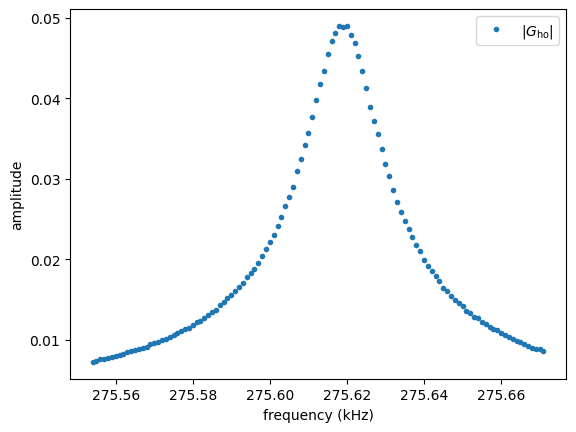

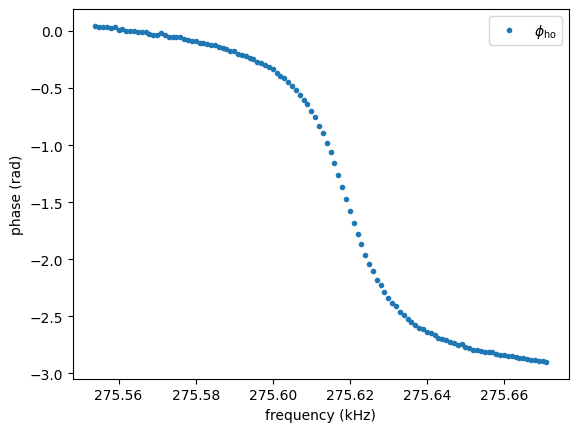

In [4]:
# Load the experimental data from CSV files.
Gho_data = load_csv(
        path=DATA_DIR/"resonance_curve.csv",
        required_columns=("frequency_hz", "amplitude", "phase_rad"),
    )

f_exp = np.asarray(Gho_data["frequency_hz"], dtype=float)
A_exp = np.asarray(Gho_data["amplitude"], dtype=float)
phi_exp = np.asarray(Gho_data["phase_rad"], dtype=float)

# Plot the experimental data.
plt.figure("amplitude")
plt.plot(f_exp * 1e-3, A_exp, ".", label=r"$|G_{\mathrm{ho}}|$")
plt.xlabel(r"frequency (kHz)")
plt.ylabel(r"amplitude")
plt.legend()
plt.figure("phase")
plt.plot(f_exp * 1e-3, phi_exp, ".", label=r"$\phi_{\mathrm{ho}}$")
plt.xlabel(r"frequency (kHz)")
plt.ylabel(r"phase (rad)")
plt.legend()


The experimental data can be fitted using the function `qafm.oscillator.Gho_fit()`, where the free response of the sensor, e.g. silicon cantilever, is fitted with the damped harmonic oscillator transfer function. The input arrays contain the excitation frequencies `f` and the corresponding positive amplitudes `Af`. Note that the returned parameter `k0` is not necessarily the spring constant unless the system has been properly calibrated.

The qAFM fit routine obtains the resonance parameters from the measured amplitude response; the fit function obtains initial estimates from the measured resonance curve:

- `f0` is initialized from the frequency at the maximum amplitude.
- `Q0` is estimated from the full width at half maximum (FWHM). If the width cannot be determined robustly, the fallback value is {math}`Q_0=10^4`.
- `k0` is estimated from the peak magnitude using the near-resonance relation {math}`\max|G_{\mathrm{ho}}|\approx Q_0/k_0`.

The nonlinear least-squares fit is performed with `scipy.optimize.curve_fit`. The fitted parameters are then used to calculate the phase response and the fitted amplitude and phase arrays are further created using the `Gho_A()` and `Gho_phi()` functions.

starting curve_fit. Initial values: f0=275620.00Hz; k0=295333N/m; Q0=14466
Fit parameters:   f0=275618.82Hz; k0=295352N/m; Q0=14504
covariances:         3.32e-04 ; 170797 ; 985
standard deviations: 1.82e-02 ; 413 ; 31


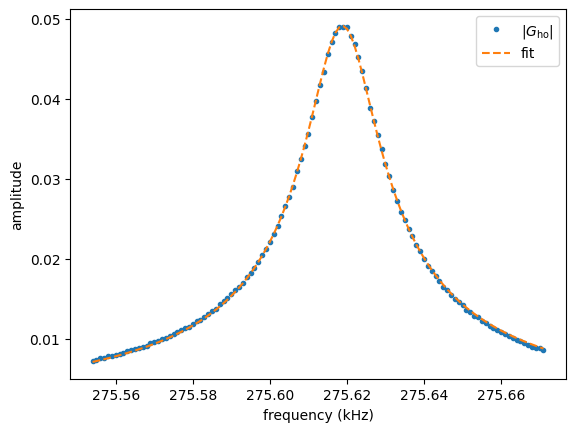

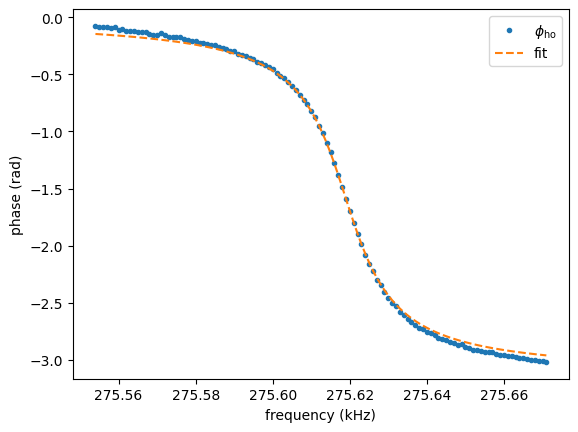

In [5]:

# Fit the experimental data to the Gho model and extract the fitted parameters.
fit_result = qafm.oscillator.Gho_fit(f_exp, A_exp, verbose=True)
fitted_sensor = fit_result.parameters

A_fit = qafm.oscillator.Gho_A(f_exp, fitted_sensor)
phi_fit = qafm.oscillator.Gho_phi(f_exp, fitted_sensor)

# artificial phase offset to match the experimental data.
phase_offset = 0.12

# Plot the experimental data and the fitted curve.
plt.figure("amplitude")
plt.plot(f_exp * 1e-3, A_exp, ".", label=r"$|G_{\mathrm{ho}}|$")
plt.plot(f_exp * 1e-3, A_fit, "--", label="fit")
plt.xlabel(r"frequency (kHz)")
plt.ylabel(r"amplitude")
plt.legend()
plt.figure("phase")
plt.plot(f_exp * 1e-3, phi_exp-phase_offset, ".", label=r"$\phi_{\mathrm{ho}}$")
plt.plot(f_exp * 1e-3, phi_fit, "--", label="fit")
plt.xlabel(r"frequency (kHz)")
plt.ylabel(r"phase (rad)")
plt.legend()

# 4.2 FM NC-AFM forward and inverse workflow

A model force can be created from the `qafm.interactions` subpackage. Representative force and force-gradient models are organized by their physical origin and many different forces are implemented, e.g. morse, LJ and vdW. Predefined custom force models combine multiple physical interactions in one model function. The following example combines a Lennard Jones type chemical interaction with a van der Waals contributions for a tip  with cone sphere geometry and calculates both the resulting force and its gradient.

In this first example, the frequency shift in the FM NC-AFM mode is evaluated with the function `qafm.fm.ktscap_to_df_approx()`. The forward calculation follows

$
F_{\mathrm{model}}(z_{\mathrm{ts}})
\rightarrow
k_{\mathrm{ts}}(z_{\mathrm{ts}})
\rightarrow
\langle k_{\mathrm{ts}}\rangle_{\cap}(z_c)
\rightarrow
\Delta f(z_c)
$

In [6]:
from qafm.interactions.combined import CombinedForce

# Use an equidistant grid for the matrix inversion.
# 5001 points over 30 nm gives dz = 6 pm, so A0 = 3 nm corresponds
# to exactly 500 grid intervals.
z_axis = np.linspace(0.1e-9, 30e-9, 5001)

sensor = qafm.oscillator.OscillatorParameters(
    f0=300_000.0,
    k0=35.0,
    Q0=20_000.0,
    A0=3e-9,
)

force_model = CombinedForce(
    forces=(
        qafm.interactions.vdw.cone_sphere_force,
        qafm.interactions.chemical.lennard_jones_force,
    ),
    gradients=(
        qafm.interactions.vdw.cone_sphere_forcegradient,
        qafm.interactions.chemical.lennard_jones_forcegradient,
    ),
)

F_model = force_model.force(z_axis)

# Same numerical differentiation route described in the manuscript.
zk, kts = qafm.numerics.numdiff(
    xin=z_axis,
    yin=F_model,
    order=1,
    method="diff",
)

zc, kts_cap = qafm.averaging.wcap(
    zk,
    kts,
    A0=sensor.A0,
)

df = qafm.fm.ktscap_to_df_approx(
    ktscap=kts_cap,
    model_par=sensor,
)

print("model points:       ", len(z_axis))
print("gradient points:    ", len(zk))
print("averaged/FM points: ", len(zc))
print("df range (Hz):      ", float(np.min(df)), "to", float(np.max(df)))

_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.17638416e-20 -1.17638416e-20]
_wcap_equiz:values <0 (len(idx[0])=2):                  [   0 1004], [-1.

The interaction force $F_{\text{even}}^\circ$ and the interaction potential $U_{\text{even}}^\circ$ can be reconstructed from the measured observable `kts_cap` under the assumptions that first only even forces are present and second, force and potential are zero at the largest sampled value of tip-sample separation. Suitable reconstruction algorithms are implemented in `qafm.fm.inversions`. The Sader–Jarvis deconvolution approach is implemented in `Feven_deconv()`, and the matrix method is implemented in `Feven_matrix_deconv()`. However, the helper function `qafm.fm.df_to_force()` can be used to reconstruct the force with the specified algorithm, e.g. `algorithm="sj"` for the Sader-Jarvis reconstruction.

In [7]:
# Sader-Jarvis reconstruction
z_sj, F_sj = qafm.fm.df_to_force(
    z=zc,
    df=df,
    sensor=sensor,
    algorithm="sj",
)

# Matrix reconstruction
try:
    z_matrix, F_matrix = qafm.fm.df_to_force(
        z=zc,
        df=df,
        sensor=sensor,
        algorithm="matrix",
    )
    matrix_ok = True
except ValueError as exc:
    matrix_ok = False
    print("Matrix inversion was skipped:")
    print(exc)

The quantitative reconstruction errors relative to the known model force are shown in the following cell.

In [8]:
# Quantitative reconstruction errors relative to the known model force.
F_model_sj = np.interp(z_sj, z_axis, F_model)
sj_error = F_sj - F_model_sj

print("Sader-Jarvis")
print(f"  RMS error: {np.sqrt(np.mean(sj_error**2)) * 1e12:.6g} pN")
print(f"  Max error: {np.max(np.abs(sj_error)) * 1e12:.6g} pN")

if matrix_ok:
    F_model_matrix = np.interp(z_matrix, z_axis, F_model)
    matrix_error = F_matrix - F_model_matrix

    print("Matrix")
    print(f"  RMS error: {np.sqrt(np.mean(matrix_error**2)) * 1e12:.6g} pN")
    print(f"  Max error: {np.max(np.abs(matrix_error)) * 1e12:.6g} pN")

Sader-Jarvis
  RMS error: 50.7086 pN
  Max error: 543.603 pN
Matrix
  RMS error: 50.1913 pN
  Max error: 539.774 pN


The model interaction, the calculated frequency shift, and the reconstructed forces for the different algorithms are plotted below. 

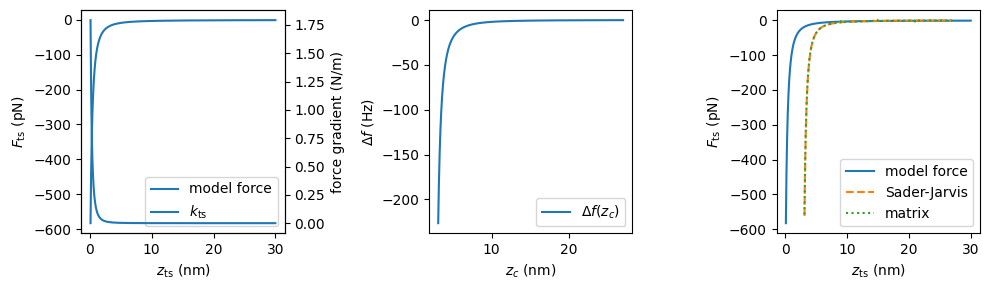

In [9]:
# Figure 3: model interaction, simulated frequency shift, and reconstruction
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.0))

ax = axes[0]
ax.plot(z_axis * 1e9, F_model * 1e12, label="model force")
ax.set_xlabel(r"$z_{\mathrm{ts}}$ (nm)")
ax.set_ylabel(r"$F_{\mathrm{ts}}$ (pN)")

ax2 = ax.twinx()
ax2.plot(zk * 1e9, kts, label=r"$k_{\mathrm{ts}}$")
ax2.set_ylabel("force gradient (N/m)")

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2)

ax = axes[1]
ax.plot(zc * 1e9, df, label=r"$\Delta f(z_c)$")
ax.set_xlabel(r"$z_c$ (nm)")
ax.set_ylabel(r"$\Delta f$ (Hz)")
ax.legend()

ax = axes[2]
ax.plot(z_axis * 1e9, F_model * 1e12, label="model force")
ax.plot(z_sj * 1e9, F_sj * 1e12, "--", label="Sader-Jarvis")
if matrix_ok:
    ax.plot(z_matrix * 1e9, F_matrix * 1e12, ":", label="matrix")
ax.set_xlabel(r"$z_{\mathrm{ts}}$ (nm)")
ax.set_ylabel(r"$F_{\mathrm{ts}}$ (pN)")
ax.legend()

fig.tight_layout()
plt.show()

In [41]:
print("Notebook completed.")

Notebook completed.
